In [1]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder

/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(al

In [3]:
final_df = pd.read_parquet('final_new.parquet')

# LightGBM

In [4]:
from sklearn.preprocessing import OrdinalEncoder
from lightgbm import LGBMClassifier
from lightgbm import early_stopping

In [5]:
def show_importances_lgbm(model=None, num : int = None) -> pd.DataFrame:
    feature_ids = model.booster_.feature_name()
    importances_value = model.feature_importances_
    
    importances = pd.DataFrame({
        'Feature Id': feature_ids,
        'Importances': importances_value
    })
    
    importances['Фичи'] = importances['Feature Id'].map(feature_names)
    importances['Фичи'] = importances['Фичи'].fillna(importances['Feature Id'])
    
    importances = importances.sort_values(
        'Importances',
        ascending=False
    ).reset_index(drop=True)
    
    return importances.head(num) if num else importances.head(min(len(importances), 30))

In [7]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [8]:
x = final_df.drop(columns=['target'])
y = final_df['target']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

## First iter

In [ ]:
crd_dc_open_qty_sum_9m, 'seg_service_channel_cd', 'seg_crm_day_qty', 'srv_mb_full_qty_sum_12m', 'dep_acct_tot_qty_sum_3m', crd_tot_act_qty_sum_6m, dep_mnth_payroll_min_qty_sum_3m

In [64]:
x_train = x_train.drop(columns=['dep_mnth_payroll_min_qty_sum_3m'])
x_val = x_val.drop(columns=['dep_mnth_payroll_min_qty_sum_3m'])
x_test = x_test.drop(columns=['dep_mnth_payroll_min_qty_sum_3m'])

In [65]:
cat_features = x_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_features = x_train.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns.tolist()

In [66]:
x_train_encoded = x_train.copy()
x_val_encoded = x_val.copy()
x_test_encoded = x_test.copy()

In [67]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
x_train_encoded[cat_features] = encoder.fit_transform(x_train_encoded[cat_features])
x_val_encoded[cat_features] = encoder.transform(x_val_encoded[cat_features])
x_test_encoded[cat_features] = encoder.transform(x_test_encoded[cat_features])

In [68]:
model_lgbm = LGBMClassifier(n_estimators = 1000,  learning_rate = 0.1, max_depth=-1, random_state = 0, num_leaves=31)
model_lgbm.fit(x_train_encoded, y_train, eval_set = [(x_val_encoded, y_val)], callbacks=[early_stopping(stopping_rounds = 100)])

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.323929 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 253108
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 1468
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[38]	valid_0's binary_logloss: 0.510374


LGBMClassifier(n_estimators=1000, random_state=0)

In [69]:
print(f"TRAIN : {roc_auc_score(y_train, model_lgbm.predict_proba(x_train_encoded)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model_lgbm.predict_proba(x_val_encoded)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model_lgbm.predict_proba(x_test_encoded)[:, 1])}")

TRAIN : 0.764660228864201
VAL : 0.7002546875199117
TEST : 0.696641497643798


In [70]:
print(f"TRAIN : {f1_score(y_train, model_lgbm.predict(x_train_encoded))}")
print(f"VAL : {f1_score(y_val, model_lgbm.predict(x_val_encoded))}")
print(f"TEST : {f1_score(y_test, model_lgbm.predict(x_test_encoded))}")

TRAIN : 0.1805862831858407
VAL : 0.1136551724137931
TEST : 0.10978982300884955


In [71]:
print(classification_report(y_test, model_lgbm.predict(x_test_encoded)))

              precision    recall  f1-score   support

         0.0       0.67      0.94      0.78     12285
         1.0       0.35      0.07      0.11      6086

    accuracy                           0.65     18371
   macro avg       0.51      0.50      0.45     18371
weighted avg       0.56      0.65      0.56     18371



In [72]:
show_importances_lgbm(model_lgbm)

,Feature Id,Importances,Фичи
0,crd_dc_act_spend_qty_sum_12m,65,crd_dc_act_spend_qty_sum_12m
1,srv_thanks_mnth_qty_sum_12m,62,srv_thanks_mnth_qty_sum_12m
2,crd_otf_total_rub_amt_sum_12m,58,crd_otf_total_rub_amt_sum_12m
3,srv_mb_econ_qty_sum_6m,47,srv_mb_econ_qty_sum_6m
4,crd_dc_mnth_snc_open_qty_sum_3m,44,crd_dc_mnth_snc_open_qty_sum_3m
5,crd_dc_mnth_snc_lst_open_qty,34,N мес с даты открытия последней текущей ДК
6,crd_dc_act_spend_qty_sum_9_12,33,crd_dc_act_spend_qty_sum_9_12
7,crd_otf_total_rub_amt_12m,28,crd_otf_total_rub_amt_12m
8,srv_sbol_mnth_1st_txn_qty,28,N мес с даты первой операции в СБОЛ
9,srv_thanks_mnth_qty_sum_9_12,26,srv_thanks_mnth_qty_sum_9_12


In [73]:
feature_importance = pd.DataFrame({
    'feature': x_train_encoded.columns,
    'importance': model_lgbm.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

In [74]:
best_features = feature_importance.loc[feature_importance['importance'] > 1, 'feature'].tolist()

In [75]:
len(best_features)

115

## Second iter

In [76]:
x_train_encoded_new = x_train_encoded[best_features]
x_val_encoded_new = x_val_encoded[best_features]
x_test_encoded_new = x_test_encoded[best_features]

In [77]:
model_lgbm = LGBMClassifier(n_estimators = 1000,  learning_rate = 0.1, max_depth=-1, random_state = 0, num_leaves=31)
model_lgbm.fit(x_train_encoded_new, y_train, eval_set = [(x_val_encoded_new, y_val)], callbacks=[early_stopping(stopping_rounds = 100)])

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018628 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23829
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 115
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[44]	valid_0's binary_logloss: 0.508401


LGBMClassifier(n_estimators=1000, random_state=0)

In [78]:
print(f"TRAIN : {roc_auc_score(y_train, model_lgbm.predict_proba(x_train_encoded_new)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model_lgbm.predict_proba(x_val_encoded_new)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model_lgbm.predict_proba(x_test_encoded_new)[:, 1])}")

TRAIN : 0.7658722763632302
VAL : 0.6979795368607212
TEST : 0.697838450664609


In [79]:
print(f"TRAIN : {f1_score(y_train, model_lgbm.predict(x_train_encoded_new))}")
print(f"VAL : {f1_score(y_val, model_lgbm.predict(x_val_encoded_new))}")
print(f"TEST : {f1_score(y_test, model_lgbm.predict(x_test_encoded_new))}")

TRAIN : 0.2579936642027455
VAL : 0.16891376240142458
TEST : 0.17515120967741937


In [80]:
print(classification_report(y_test, model_lgbm.predict(x_test_encoded_new)))

              precision    recall  f1-score   support

         0.0       0.67      0.91      0.77     12285
         1.0       0.38      0.11      0.18      6086

    accuracy                           0.64     18371
   macro avg       0.52      0.51      0.47     18371
weighted avg       0.57      0.64      0.57     18371



## Third iter

In [82]:
def simple_train_lgbm(target_column = 'target', features = None, model_params = None):
    features = x_train_encoded_new.columns.tolist() if features is None else features
    text_columns = x_train_encoded_new[features].select_dtypes('object').columns.tolist()
    
    x_train_part = x_train_encoded_new[features]
    x_val_part = x_val_encoded_new[features]
    x_test_part = x_test_encoded_new[features]

    model_lgbm = LGBMClassifier(n_estimators = 1000,  learning_rate = 0.1, max_depth=-1, random_state = 0, num_leaves=31)
    
        
    model_lgbm.fit(x_train_part, y_train, eval_set = [(x_val_part, y_val)], callbacks=[early_stopping(stopping_rounds = 100)])

    
    
    train_preds = model_lgbm.predict(x_train_part)
    train_probas = model_lgbm.predict_proba(x_train_part)[:, 1]
    
    val_preds = model_lgbm.predict(x_val_part)
    val_probas = model_lgbm.predict_proba(x_val_part)[:, 1]
    
    
    test_preds = model_lgbm.predict(x_test_part)
    test_probas = model_lgbm.predict_proba(x_test_part)[:, 1]
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_lgbm

In [83]:
target_column = 'target' 
RANDOM_STATE = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances_lgbm(model_lgbm, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 5)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train_lgbm(target_column, used_features)

    train_f1.append(f1_score(y_train, train_preds))
    val_f1.append(f1_score(y_val, val_preds))
    test_f1.append(f1_score(y_test, test_preds))


    train_roc_auc.append(roc_auc_score(y_train, train_probas))
    val_roc_auc.append(roc_auc_score(y_val, val_probas))
    test_roc_auc.append(roc_auc_score(y_test, test_probas))

  0%|          | 0/23 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[118]	valid_0's binary_logloss: 0.592853


  4%|▍         | 1/23 [00:00<00:17,  1.23it/s]

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000354 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1282
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds


  9%|▊         | 2/23 [00:01<00:14,  1.47it/s]

...

 91%|█████████▏| 21/23 [00:25<00:03,  1.64s/it]

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22591
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[45]	valid_0's binary_logloss: 0.508096


 96%|█████████▌| 22/23 [00:27<00:01,  1.70s/it]

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013901 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23053
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 111
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[43]	valid_0's binary_logloss: 0.508143


100%|██████████| 23/23 [00:29<00:00,  1.27s/it]


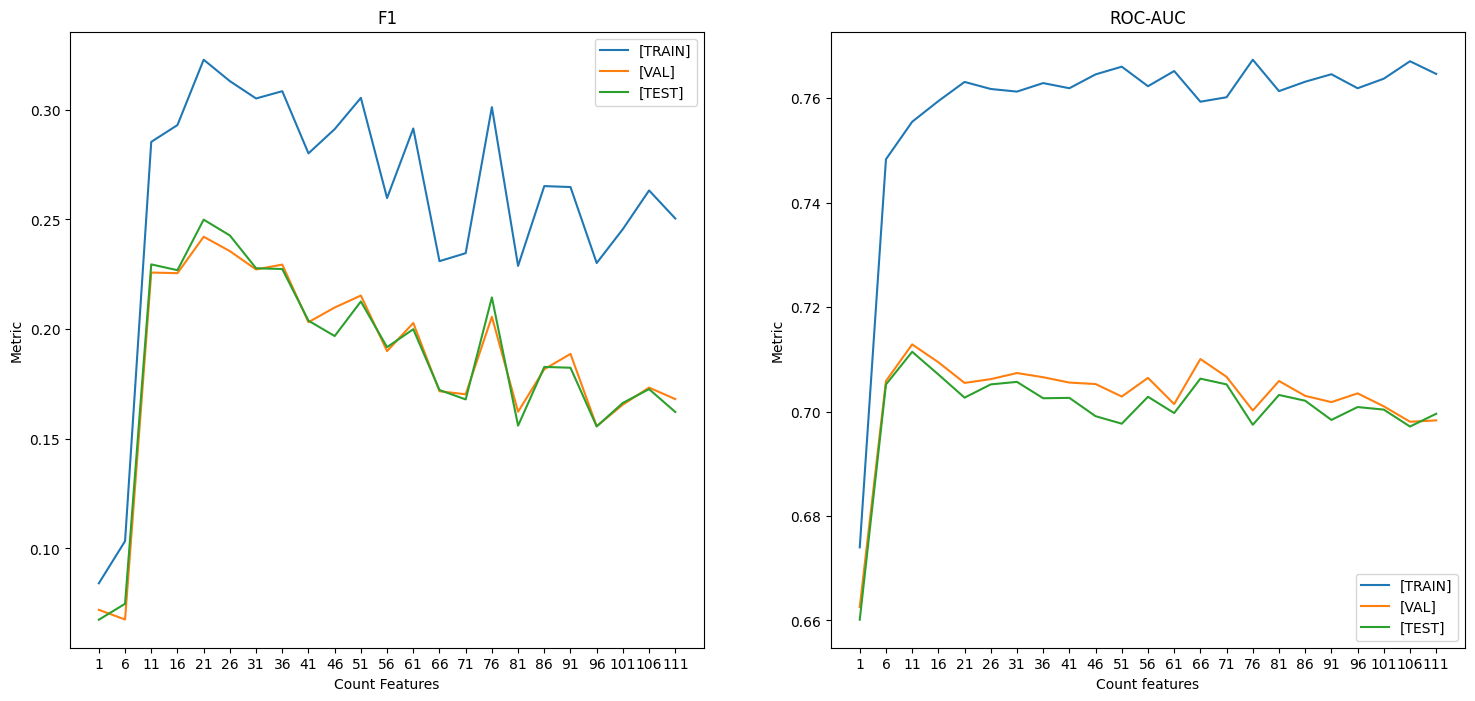

In [84]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )


plt.ylabel('Metric')
plt.xlabel('Count features')


axs[0].plot(train_f1, label = '[TRAIN]')
axs[0].plot(val_f1, label = '[VAL]')
axs[0].plot(test_f1, label = '[TEST]')

axs[0].set_title('F1')
axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
axs[0].set_xlabel('Count Features')
axs[0].set_ylabel('Metric')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Count features')
axs[1].set_ylabel('Metric')

axs[1].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)

axs[0].legend()

axs[1].legend();

In [98]:
num_features = 11
final_features = importances[:num_features]

In [99]:
final_features

['srv_thanks_mnth_qty_sum_12m',
 'crd_otf_total_rub_amt_sum_12m',
 'srv_mb_econ_qty_sum_6m',
 'crd_dc_act_spend_qty_sum_12m',
 'crd_dc_mnth_snc_open_qty_sum_3m',
 'crd_dc_mnth_snc_lst_open_qty',
 'crd_otf_total_rub_amt_12m',
 'srv_sbol_mnth_1st_txn_qty',
 'crd_cc_clsd_qty_sum_3m',
 'crd_dc_act_spend_qty_sum_9_12',
 'seg_client_sb_segment_cd']

## Last

In [100]:
x_train_encoded_new = x_train_encoded[final_features]
x_val_encoded_new = x_val_encoded[final_features]
x_test_encoded_new = x_test_encoded[final_features]

In [101]:
model_lgbm = LGBMClassifier(n_estimators = 1000,  learning_rate = 0.1, max_depth=-1, random_state = 0, num_leaves=31)
model_lgbm.fit(x_train_encoded_new, y_train, eval_set = [(x_val_encoded_new, y_val)], callbacks=[early_stopping(stopping_rounds = 100)])

[LightGBM] [Info] Number of positive: 18405, number of negative: 36707
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2134
[LightGBM] [Info] Number of data points in the train set: 55112, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333956 -> initscore=-0.690345
[LightGBM] [Info] Start training from score -0.690345
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[55]	valid_0's binary_logloss: 0.505251


LGBMClassifier(n_estimators=1000, random_state=0)

In [102]:
# 11
print(f"TRAIN : {roc_auc_score(y_train, model_lgbm.predict_proba(x_train_encoded_new)[:, 1])}")
print(f"VAL : {roc_auc_score(y_val, model_lgbm.predict_proba(x_val_encoded_new)[:, 1])}")
print(f"TEST : {roc_auc_score(y_test, model_lgbm.predict_proba(x_test_encoded_new)[:, 1])}")

TRAIN : 0.7555077101341003
VAL : 0.7128700336506806
TEST : 0.7114549013990354


In [103]:
# 11
print(f"TRAIN : {f1_score(y_train, model_lgbm.predict(x_train_encoded_new))}")
print(f"VAL : {f1_score(y_val, model_lgbm.predict(x_val_encoded_new))}")
print(f"TEST : {f1_score(y_test, model_lgbm.predict(x_test_encoded_new))}")

TRAIN : 0.28538255194779194
VAL : 0.225790987535954
TEST : 0.22951610956920482


In [104]:
print(classification_report(y_test, model_lgbm.predict(x_test_encoded_new)))

              precision    recall  f1-score   support

         0.0       0.68      0.90      0.78     12285
         1.0       0.43      0.16      0.23      6086

    accuracy                           0.65     18371
   macro avg       0.56      0.53      0.50     18371
weighted avg       0.60      0.65      0.59     18371



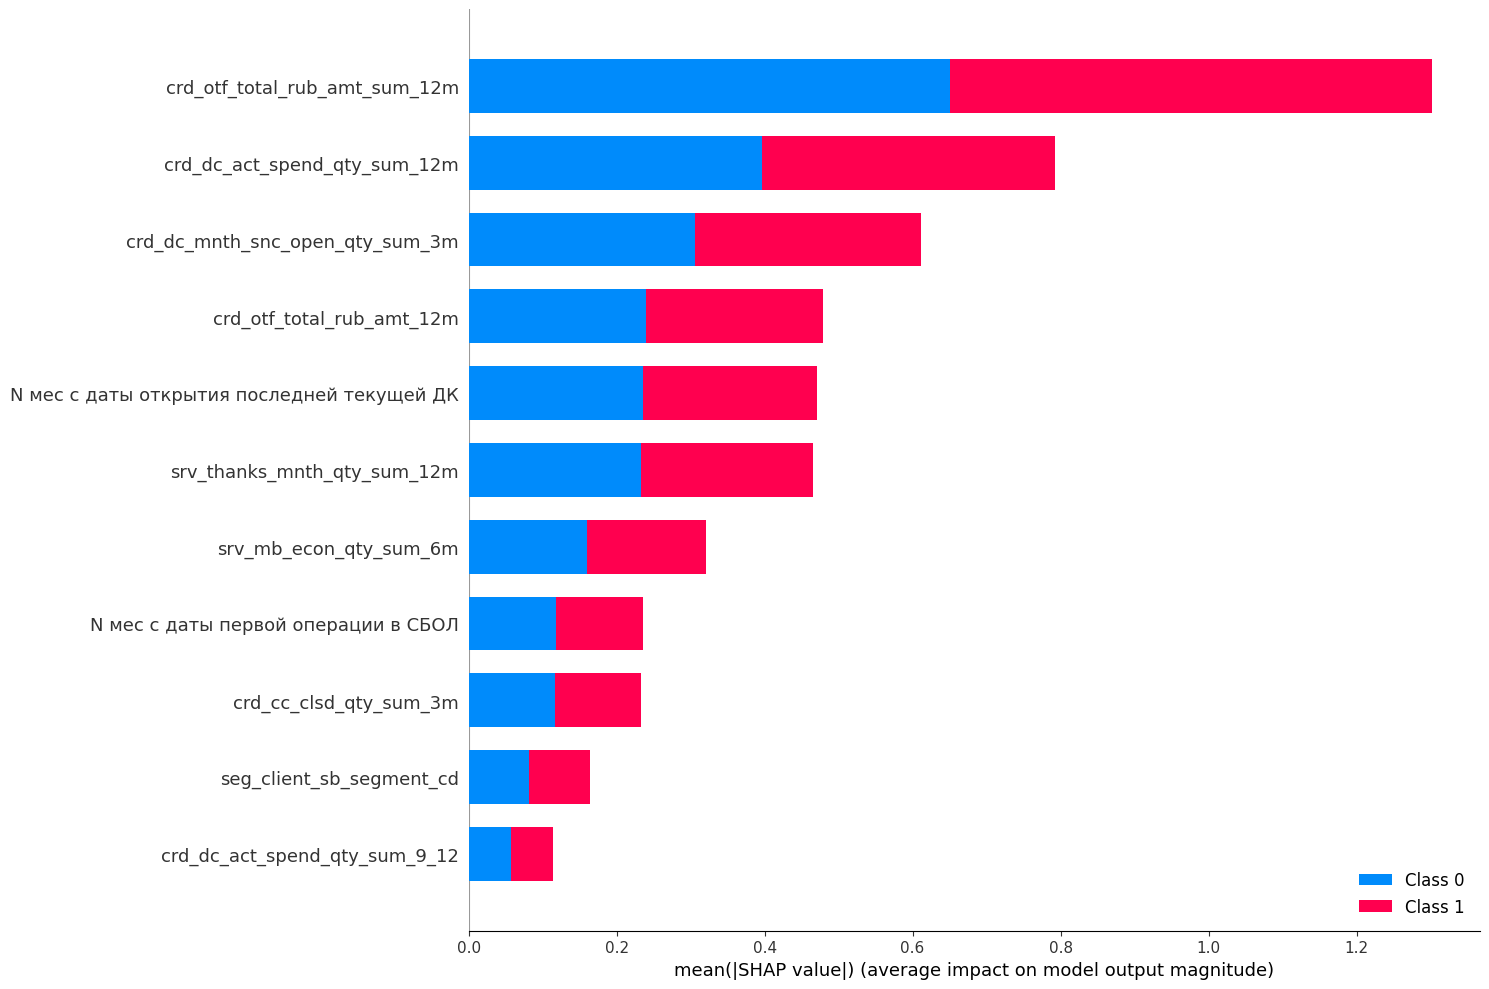

In [105]:
explainer = shap.TreeExplainer(model_lgbm)
shap_values = explainer.shap_values(x_test_encoded_new)

shap.summary_plot(shap_values, x_test_encoded_new.rename(columns=feature_names), plot_size=(15, 10))

In [106]:
print(confusion_matrix(y_test, model_lgbm.predict(x_test_encoded_new)))

[[11035  1250]
 [ 5135   951]]
